# MAST 387 Midterm Exam
## Student: Tessa Skelly (40265993)

## Problem A
### Problem A-1

In [1]:
# list of vowels
vowels =['a', 'e', 'i', 'o', 'u', 'y']

def Canadish_1(sentence_in):

    # split sentence into words
    words = sentence_in.split()
    # empty list for sentence_out
    sentence_out =[]

    # check for vowel at beginning of each word
    for word in words:
        if word[0] in vowels:
            word = word + "eh"
        sentence_out.append(word)

    return " ".join(sentence_out)

testA1 = Canadish_1("this is almost a canadish sentence")
print(testA1)

this iseh almosteh aeh canadish sentence


### Problem A-2

In [2]:
# list of consonants
alphabet = set('abcdefghijklmnopqrstuvwxyz')
consonants = alphabet-set(vowels)

def Canadish_12(sentence_in):
    # apply rule 1 to the sentence
    sentence_in = Canadish_1(sentence_in)
    # split sentence into words
    words = sentence_in.split()
    # empty list for sentence_out
    sentence_out = []

    # check for consonant at beginning of each word
    for word in words:
        if word[0] in consonants:
            index = 0
            # get all first consonants
            while index<len(word) and word[index] in consonants:
                index+=1

            # cut word after cluster and concatenate it
            word = word[index:] + word[:index] + "ey"
    
        # add to sentence
        sentence_out.append(word)

    return " ".join(sentence_out)

testA2 = Canadish_12("this is a canadish sentence")
print(testA2)


isthey iseh aeh anadishcey entencesey


### Problem A-3

In [7]:
def Canadish_12_case(sentence_in):

    # split sentence into words
    words = sentence_in.split()

    # empty list for sentence_out
    sentence_out = []

    for word in words:
        word_translate = Canadish_12(word.lower())
        # check for all upper case letters
        if word.isupper():
            word = word_translate.upper()

        # check for first letter upper case
        elif word[0].isupper():
                word = word_translate.capitalize()
        
        else:
            word = word_translate

        # add to sentence_out
        sentence_out.append(word)

    return " ".join(sentence_out)

testA3 = Canadish_12_case("The weather in Montreal is AWESOME")
print(testA3)

Ethey eatherwey ineh Ontrealmey iseh AWESOMEEH


### Problem A-4

In [8]:
def Canadish(sentence_in):
    # split sentence into words (includes special characters)
    words = sentence_in.split()

    # empty list sentence_out
    sentence_out = []

    for word in words:
        # check if all letters are part of the alphabet
        if word.isalpha():
            word = Canadish_12_case(word)
            
        # if there is a special character in the word
        else:
            # current word between special characters
            current =""
            # translated word
            new_word =""

            # check each character in the word for a special character and add all alpha characters to a current word
            for c in word:
                if c.isalpha():
                    current+=c
                else:
                    # check if there's a current word to be translated before adding special characters
                    if current:
                        new_word += Canadish_12_case(current)
                        current = ""
                    new_word += c
            # check if the sentence ended with any words to be translated after a special character
            if current:
                new_word += Canadish_12_case(current)
            word = new_word

        # add to sentence_out
        sentence_out.append(word)

    return " ".join(sentence_out)
    
testA4 = Canadish("Here is a Canadish sentence with bells and whistles--YES, this is it! You made it.")
print(testA4)

Erehey iseh aeh Anadishcey entencesey ithwey ellsbey andeh istleswhey--YESEH, isthey iseh iteh! Youeh ademey iteh.


## Problem B

In [9]:
import numpy as np
import matplotlib.pyplot as plt

### Problem B-1

In [10]:
def steepest_GD(A, b, TOL, Nmax):
    # initial approximation 
    x0 = np.zeros_like(b)
    # residual
    r = b - A @ x0
    # number of iterations 
    n=0
    # list of approximations
    X = [x0]
    # two norm residual
    tn = np.linalg.norm(r)

    # solve
    while tn > TOL and n < Nmax:
        # scalar
        a = (r.T @ r)/(r.T @ A @ r)
        x1 = x0 + a * r
        # update residual and two-norm and n
        r = b - A @ x1
        tn = np.linalg.norm(r)
        n += 1
        # store approximation
        X.append(x1)
        # update x0
        x0 = x1
    return np.array(X)
        
# test
A = np.array([
    [2,1,0,0],
    [1,2,1,0],
    [0,1,2,1],
    [0,0,1,2] ])
b = np.ones(4)

X = steepest_GD(A, b, 1e-8, 1000)
print(X)

[[0.         0.         0.         0.        ]
 [0.28571429 0.28571429 0.28571429 0.28571429]
 [0.38095238 0.19047619 0.19047619 0.38095238]
 [0.39455782 0.20408163 0.20408163 0.39455782]
 [0.39909297 0.19954649 0.19954649 0.39909297]
 [0.39974085 0.20019436 0.20019436 0.39974085]
 [0.39995681 0.1999784  0.1999784  0.39995681]
 [0.39998766 0.20000926 0.20000926 0.39998766]
 [0.39999794 0.19999897 0.19999897 0.39999794]
 [0.39999941 0.20000044 0.20000044 0.39999941]
 [0.3999999  0.19999995 0.19999995 0.3999999 ]
 [0.39999997 0.20000002 0.20000002 0.39999997]
 [0.4        0.2        0.2        0.4       ]
 [0.4        0.2        0.2        0.4       ]]


### Problem B-2

<function matplotlib.pyplot.show(close=None, block=None)>

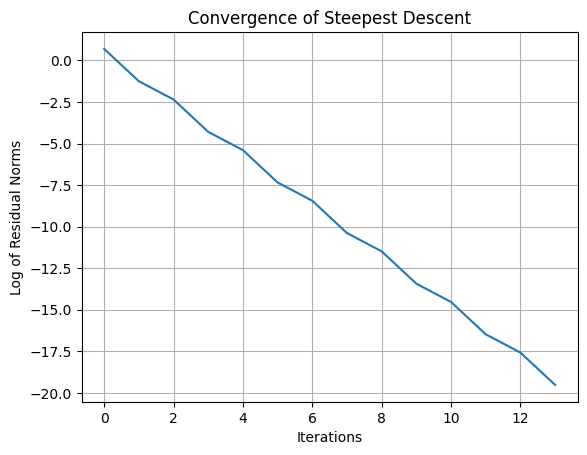

In [12]:
# get residual norms
rn = [np.linalg.norm(b - A @ x) for x in X]

# get their log
rn = np.array(rn)
rn_log = np.log(rn)

# plot
fig, ax = plt.subplots()
ax.plot(rn_log)
ax.set_xlabel("Iterations")
ax.set_ylabel("Log of Residual Norms")
ax.set_title("Convergence of Steepest Descent")
ax.grid(True)
plt.show


The log of the residual does seem to converge to 0 exponentially since the relationship between the log of residual norms and the number of iterations goes down linearly, reaching close to $e^{-20}$ after about 13 iterations.

### Problem B-3

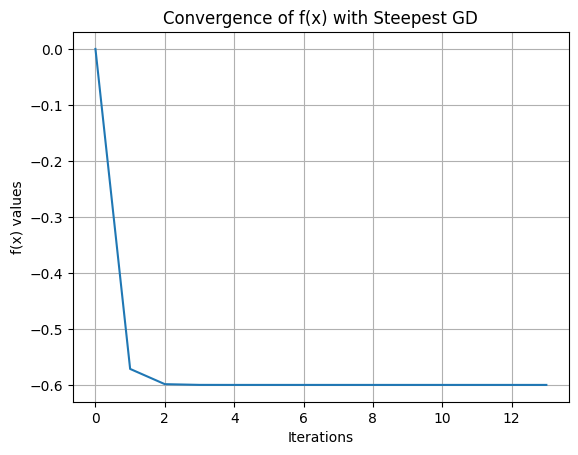

In [15]:
# function values
f = [(1/2) * x.T @ A @ x - x.T @ b for x in X]

fig, ax = plt.subplots()
ax.plot(f)
ax.set_xlabel("Iterations")
ax.set_ylabel("f(x) values")
ax.set_title("Convergence of f(x) with Steepest GD")
ax.grid(True)
plt.show()

Steep gradient descent does seem to minimize function f as you can see the f values decrease in less than 2 iterations and level very quick.
The approximate minimum value of f from this graph is -0.6.

### Problem B-4

In [16]:
def test_matrix(n, k, c):
    # array of indexes
    index = np.arange(n)
    i = index.reshape(n,1)
    j = index.reshape(1,n)

    # difference between indexes for rows and columns
    diff = np.abs(i-j)

    # create matrix
    A0 = np.zeros((n,n))

    # condition 1: k^c
    A0[diff == 0] = k**c

    # condition 2: k-l = k -|i-j| if l <= k
    c2 = (diff > 0) & (diff <= k)
    A0[c2] = k - diff[c2]

    return A0

test1B4 = test_matrix(4,2,2)
print("Matrix 1:\n", test1B4)

test2B4 = test_matrix(6,4,3)
print("\nMatrix 2:\n",test2B4)
    

Matrix 1:
 [[4. 1. 0. 0.]
 [1. 4. 1. 0.]
 [0. 1. 4. 1.]
 [0. 0. 1. 4.]]

Matrix 2:
 [[64.  3.  2.  1.  0.  0.]
 [ 3. 64.  3.  2.  1.  0.]
 [ 2.  3. 64.  3.  2.  1.]
 [ 1.  2.  3. 64.  3.  2.]
 [ 0.  1.  2.  3. 64.  3.]
 [ 0.  0.  1.  2.  3. 64.]]


### Problem B-5

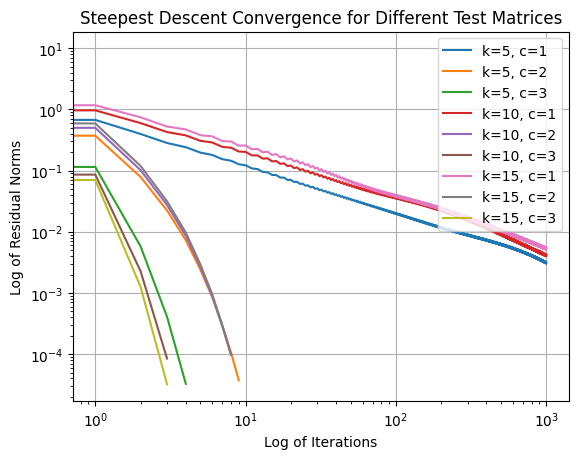

In [17]:
# first k value
k=5
# plot
fig, ax = plt.subplots()
# array of ones
b1 = np.ones(100)

# to store steepest gradients and residual norms
Xi =[]
ri = []

# loop to keep adding to the plots
for k in range(5, 16, 5):
    for c in range(1, 4):
        # get all arrays from combinations of c and k with test_matrix
        A = test_matrix(100, k, c)
        # get all steepest gradients
        X = steepest_GD(A, b1, 1e-4, 1000)
        res = [np.linalg.norm(b1 - A @ x) for x in X]
        # create labels to add to graph
        label = f"k={k}, c={c}"
        ax.plot(res, label = label)

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("Log of Iterations")
ax.set_ylabel("Log of Residual Norms")
ax.set_title("Steepest Descent Convergence for Different Test Matrices")
ax.legend(loc = "upper right")
ax.grid(True)
plt.show()

The graph makes it obvious that the residual norms converge faster when c=3, if we refer to the legend. The value for k does not seem to make a difference since for all different values of c, all curves of the residual norms follow similar trends. The maximum amount of iterations is reached before the tolerance limit for c=1 since the curves reach the end of the x-axis, showing slower convergence.

### Problem B-6

In [20]:
# matrices where c=1
c1 = [test_matrix(100, 5, 1), test_matrix(100, 10, 1), test_matrix(100, 15, 1)]
c1_cond = [float(np.linalg.cond(A)) for A in c1]
print("c=1:", c1_cond)
# c=2
c2=[test_matrix(100, 5, 2), test_matrix(100, 10, 2), test_matrix(100, 15, 2)]
c2_cond = [float(np.linalg.cond(A)) for A in c2]
print("\nc=2:", c2_cond)

# c=3
c3 = [test_matrix(100, 5, 3), test_matrix(100, 10, 3), test_matrix(100, 15, 3)]
c3_cond = [float(np.linalg.cond(A)) for A in c3]
print("\nc=3:", c3_cond)

c=1: [4041.835272922984, 4839.826249924888, 5699.105835943091]

c=2: [2.2469508407601513, 2.1023825837799093, 2.0538686245121927]

c=3: [1.2078785973895028, 1.1002373586160277, 1.065878211739134]


A smaller condition number does correspond to a faster convergence of the algorithm which we can tell by comparing the algorithms separated by their c-value. Those with parameter c=1 are the slowest to converge as seen on the graph and have the highest condition numbers while those with c=3 having the fastest convergence have the smallest condition numbers.

## Problem C

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Problem C-1

In [24]:
netflix = pd.read_csv("C:\\Users\\tessa\\Downloads\\sem 5 concordia\\mast 387\\midterm\\netflix.csv")

### Problem C-2

In [30]:
tv = netflix[netflix["type"] == "TV Show"]
movies = netflix[netflix["type"] == "Movie"]
total = len(netflix)

print("Percentage of TV shows added to Netflix: %.2f %%" % ((len(tv)/total)*100))

print("\nPercentage of movies added to Netflix: %.2f %%" % ((len(movies)/total)*100))

Percentage of TV shows added to Netflix: 32.52 %

Percentage of movies added to Netflix: 67.48 %


In [31]:
netflix["type"].value_counts()

type
Movie      3939
TV Show    1898
Name: count, dtype: int64

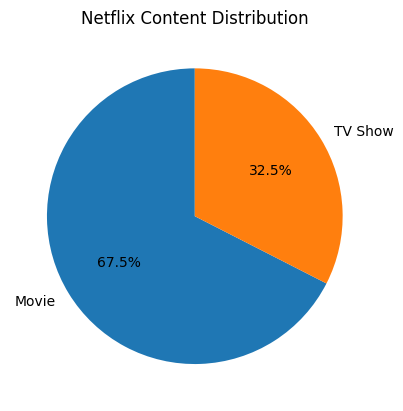

In [34]:
# pie chart for visual representation
# number of tv shows and movies
netflix_counts = netflix["type"].value_counts()

fig, ax = plt.subplots()
ax.pie(netflix_counts, labels=netflix_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Netflix Content Distribution")
plt.show()

### Problem C-3

In [35]:
netflix["date_added_dt"] = pd.to_datetime(netflix["date_added"])
netflix["year_added"] = netflix["date_added_dt"].dt.year
netflix["month_added"] = netflix["date_added_dt"].dt.month

# to get season count
def season_count(duration):
    # turn the first part of the string into an integer
    if "Season" in duration:
        words = duration.split()
        return int(words[0])
    else:
        return np.nan

netflix["season_count"] = netflix["duration"].apply(season_count)

# to get duration minutes
def duration_min(duration):
    # turn first part of string to int
    if "min" in duration:
        words = duration.split()
        return int(words[0])
    else:
        return np.nan

netflix["duration_min"] = netflix["duration"].apply(duration_min)
netflix.head()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type,date_added_dt,year_added,month_added,season_count,duration_min
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show,2019-11-30,2019.0,11.0,1.0,NaN
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie,2019-11-30,2019.0,11.0,NaN,67.0
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie,2019-11-30,2019.0,11.0,NaN,135.0
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie,2019-11-29,2019.0,11.0,NaN,106.0
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show,NaT,NaN,NaN,2.0,NaN


### Problem C-4

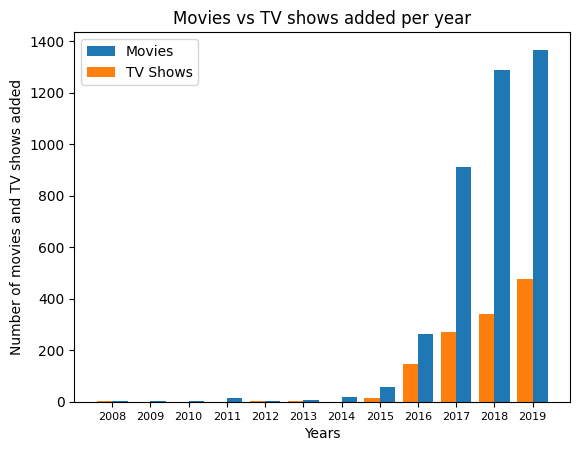

In [37]:
yearsC4 = range(2008, 2020)
movies_added =[]
shows_added =[]

# add number of movies and tv shows added each year to each list
for year in yearsC4:
    movies_added.append(len(netflix[(netflix["type"]=="Movie") & (netflix["year_added"]==year)]))
    shows_added.append(len(netflix[(netflix["type"]=="TV Show") & (netflix["year_added"]==year)]))
    
C4_data = pd.DataFrame({"Year Added": yearsC4, 
                     "Movies": movies_added, 
                     "TV Shows": shows_added})
# years as x-values
xc4 = np.arange(len(yearsC4))
colC4 = list(yearsC4)

fig, ax=plt.subplots()
ax.bar(xc4+0.2, C4_data["Movies"], width = 0.4, label = "Movies")
ax.bar(xc4-0.2, C4_data["TV Shows"], width = 0.4, label = "TV Shows")
ax.legend()
ax.set_ylabel("Number of movies and TV shows added")
ax.set_xlabel("Years")
ax.set_title("Movies vs TV shows added per year")
ticks=xc4
ax.set_xticks(ticks)
labels = ax.set_xticklabels(colC4, size=8)


There is a much higher number of movies being added to Netflix than TV shows. The bar chart also shows that there was not much media being added until about 2016, which from there, it grows very quickly.

### Problem C-5

In [38]:
release_years_sorted = netflix.sort_values(by="release_year")
print(release_years_sorted["release_year"].head())
print(release_years_sorted["release_year"].tail())

2154    1925
4929    1942
4931    1942
4943    1943
4941    1943
Name: release_year, dtype: int64
1276    2019
8       2019
26      2019
27      2019
133     2020
Name: release_year, dtype: int64


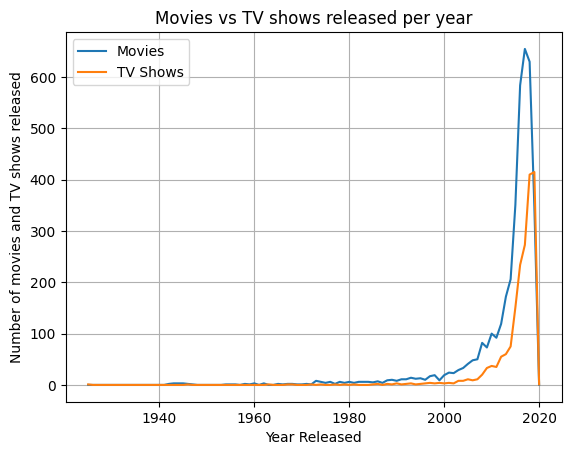

In [40]:
# because the years range from 1925 to 2020
yearsC5 = range(1925, 2021)
movies_released = []
shows_released = []

# add number movies and tv shows released by year to each list
for year in yearsC5:
    movies_released.append(len(netflix[(netflix["type"]=="Movie") & (netflix["release_year"]==year)]))
    shows_released.append(len(netflix[(netflix["type"]=="TV Show") & (netflix["release_year"]==year)]))

C5_data = pd.DataFrame({"Year Released": yearsC5,
                        "Movies": movies_released,
                        "TV Shows": shows_released})

# years as x-values
colC5 = list(yearsC5)
xc5 = np.arange(len(yearsC5))

fig, ax = plt.subplots()
ax.plot(C5_data["Year Released"], C5_data["Movies"], label = "Movies")
ax.plot(C5_data["Year Released"], C5_data["TV Shows"], label = "TV Shows")
ax.set_xlabel("Year Released")
ax.set_ylabel("Number of movies and TV shows released")
ax.set_title("Movies vs TV shows released per year")
ax.legend()
ax.grid(True)


The amount of movies and TV shows released both have a sudden rise between 2000 and 2010 which then increases even more rapidly after 2010. From 1925 to about the 1990s, there is a very small number of movies released then, from the graph we see that there is a very small increase that starts around the 1970s. For TV shows, it looks like practically none are released until the 1990s and early 2000s mostly.

### Problem C-6

In [41]:
oldest_shows = [release_years_sorted[release_years_sorted["type"] == "TV Show"]["title"][:10]]
oldest_shows

[2154      Pioneers: First Women Filmmakers*
 5143    Pioneers of African-American Cinema
 4593    The Twilight Zone (Original Series)
 4589                 The Andy Griffith Show
 4266                              Star Trek
 2623       Monty Python's Fliegender Zirkus
 2624           Monty Python's Flying Circus
 3503                             Dad's Army
 3921                               El Chavo
 2182                          Ninja Hattori
 Name: title, dtype: object]

### Problem C-7

In [42]:
keanu_movies = []
# return true if keanu is in the cast
def find_keanu(cast):
    # in case title does not contain a string
    if type(cast) == str:
        return "Keanu Reeves" in cast
    return False
    

# applyd
keanu_true = netflix["cast"].apply(find_keanu)
keanu_movies = list(netflix[keanu_true]["title"])
print(keanu_movies)
    

['The Gift', 'The Matrix', 'The Matrix Reloaded', 'The Matrix Revolutions', 'The Lake House', "Something's Gotta Give", 'Always Be My Maybe', 'Man of Tai Chi', 'SPF-18', 'The Bad Batch', 'To the Bone']


### Problem C-8

In [43]:
yearsC8 = list(range(2008, 2020))
data_C8 = pd.DataFrame(index = yearsC8)
data_C8.index.name = "year_added"

# get movies only dataframe
movies_C8 = netflix[netflix["duration_min"].notna()]

# mean_duration
# empty lists for data
mean_C8 = []
std_C8 = []
movies_added_C8 = []
min_added_C8 = []

# for each year append data
for year in yearsC8:
    movies_durations = movies_C8[movies_C8["year_added"] == year]["duration_min"]
    mean_C8.append(np.mean(movies_durations))
    std_C8.append(np.std(movies_durations))
    movies_added_C8.append(len(movies_C8[movies_C8["year_added"]==year]))
    min_added_C8.append(np.sum(movies_durations))
    
data_C8["mean_duration"] = mean_C8
data_C8["std_duration"] = std_C8
data_C8["movies_added"] = movies_added_C8
data_C8["min_added"] = min_added_C8

In [44]:
print(data_C8)
print("\nCorrelation between movies_added and min_added:",data_C8["movies_added"].corr(data_C8["min_added"]))

            mean_duration  std_duration  movies_added  min_added
year_added                                                      
2008            81.000000      0.000000             1       81.0
2009            66.500000     37.500000             2      133.0
2010            84.000000      0.000000             1       84.0
2011            93.461538      5.891524            13     1215.0
2012            76.500000     33.537293             4      306.0
2013            83.500000     26.493710             6      501.0
2014            77.000000     21.351692            19     1463.0
2015            82.758621     24.178439            58     4800.0
2016            84.143939     24.387693           264    22214.0
2017            97.125958     27.572875           913    88676.0
2018           101.986822     29.671415          1290   131563.0
2019            98.786394     25.408090          1367   135041.0

Correlation between movies_added and min_added: 0.9995241154702342


The correlation is nearly 1, showing a linear relationship between both factors. This makes sense since netflix is adding more movies with means and standard deviations of durations with what seems like mostly low variance. This results in the durations minutes increasing linearly with the amount of movies added, as shown on the graph below.

Text(0.5, 1.0, 'Full amount of minutes of movies vs Amount of movies added')

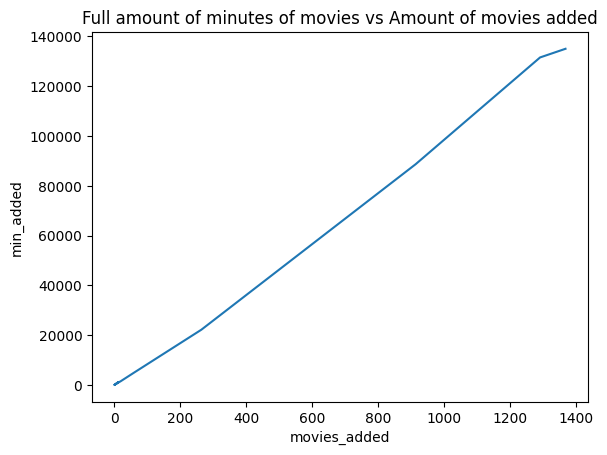

In [47]:
# visualizations
fig, ax = plt.subplots()
ax.plot(data_C8["movies_added"], data_C8["min_added"])
ax.set_ylabel("min_added")
ax.set_xlabel("movies_added")
ax.set_title("Full amount of minutes of movies vs Amount of movies added")


### Problem C-9

In [48]:
# directors dataframe
directors_C9 = netflix[netflix["director"].notna()]

# empty dictionary
dict_C9= {}

for i in range(len(directors_C9)):
    # get director and title for each row
    director = directors_C9.iloc[i]["director"]
    title = directors_C9.iloc[i]["title"]

    # add to director key to dictionary if it isn't already there
    if director not in dict_C9:
        dict_C9[director] = []

    # add value to corresponding key
    dict_C9[director].append(title)

# get Sidharth Malhotra and Steven Spielberg
print("Sidharth Malhotra:\n", dict_C9["Sidharth Malhotra"])
print("\nSteven Spielberg:\n",dict_C9["Steven Spielberg"])

Sidharth Malhotra:
 ['We Are Family']

Steven Spielberg:
 ['The Adventures of Tintin', 'War Horse', 'Indiana Jones and the Kingdom of the Crystal Skull', 'Indiana Jones and the Last Crusade', 'Indiana Jones and the Raiders of the Lost Ark', 'Indiana Jones and the Temple of Doom', "Schindler's List", 'Lincoln']


### Problem C-10

director
Raúl Campos, Jan Suter    18
Marcus Raboy              14
Jay Karas                 13
Jay Chapman               12
Steven Spielberg           8
Martin Scorsese            8
Johnnie To                 8
dtype: int64


Text(0.5, 0, 'Number of movies')

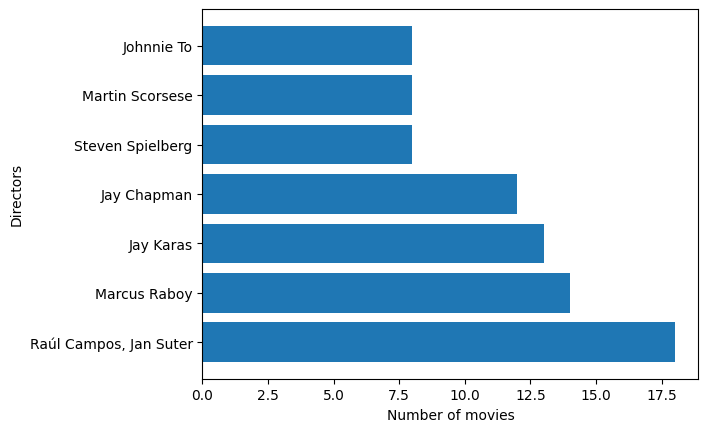

In [49]:
# directors dataframe
directors_C10 = netflix[netflix["director"].notna()]

# get indices and values
directors_i = directors_C10["director"].value_counts().index
directors_v = directors_C10["director"].value_counts().values

# create series
series_C10 = pd.Series(directors_v, index = directors_i)

# directors with over 7 movies
more_than_7 = series_C10[directors_v>7]
print(more_than_7)

fig, ax=plt.subplots()
ax.barh(more_than_7.index, more_than_7.values)
ax.set_ylabel("Directors")
ax.set_xlabel("Number of movies")


### Problem C-11

In [50]:
# how many movies or TV shows have "New York City" in the description per release year
# showing with stacked bar plot
def new_york_mention(description):
    return "New York City" in description

# get all tv and movies mentioning new york city in description
new_york_mentions = netflix[netflix["description"].apply(new_york_mention)]

# get years where these were released
years1_C11 = sorted(new_york_mentions["release_year"].unique())

# add number of movies released mentioning new york each year
new_york_movies = new_york_mentions[new_york_mentions["type"]=="Movie"]
nyc_movie_year = [len(new_york_movies[new_york_movies["release_year"]==year]) for year in years1_C11]

new_york_tv = new_york_mentions[new_york_mentions["type"]=="TV Show"]
nyc_tv_year =[len(new_york_tv[new_york_tv["release_year"]==year]) for year in years1_C11]




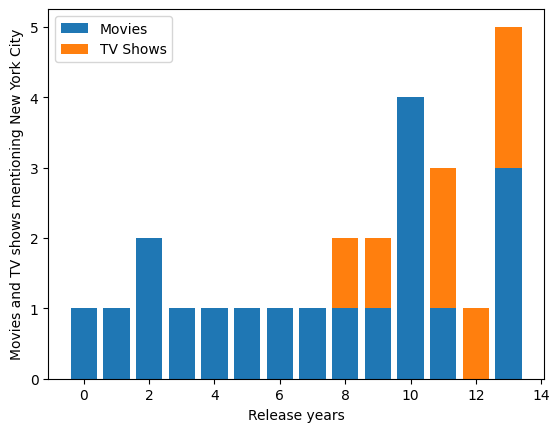

In [51]:
fig, ax=plt.subplots()
ax.bar(np.arange(len(years1_C11)), nyc_movie_year, label="Movies")
ax.bar(np.arange(len(years1_C11)), nyc_tv_year, bottom=nyc_movie_year, label="TV Shows")
ax.set_xlabel("Release years")
ax.set_ylabel("Movies and TV shows mentioning New York City")
ax.legend()

I wanted to produce a stack plot to see if the separation between two variables (TV Shows and Movies here) is more clear than with a side-by-side bar chart. I thought it would be interesting to see if the variables were as easy to read. With this data, I feel like it would show it more clearly if there was more data and a bigger difference bewteen the TV show numbers and the Movies numbers.

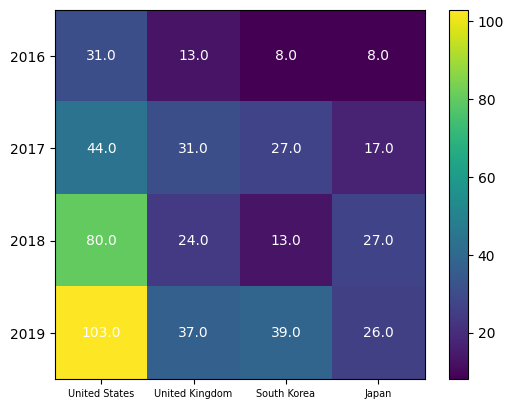

In [52]:
# 4 countries with the most tv shows added to netflix from 2016 to 2019
tv_shows = netflix[(netflix["type"]=="TV Show") & (netflix["year_added"].between(2016,2019))]

# get 4 countries with most tv shows added
top_countries = tv_shows["country"].value_counts().head(4).index

# get tv shows from those countries only
tv_top_countries = tv_shows[tv_shows["country"].isin(top_countries)]

# get years of release
years2_C11 = list(range(2016,2020))

# create array
arr = np.zeros((len(years2_C11), len(top_countries)))
# get indices for array with years as rows and countries as columns
for i in range(len(years2_C11)):
    year=years2_C11[i]
    for j in range(len(top_countries)):
        country=top_countries[j]
        # add amount of tv shows for country and year added
        arr[i,j]=len(tv_shows[(tv_shows["year_added"]==year) & (tv_shows["country"]==country)])

fig, ax=plt.subplots()
heatmap=ax.imshow(arr)

ax.set_xticks(np.arange(len(top_countries)))
ax.set_xticklabels(top_countries, size=7)
ax.set_yticks(np.arange(len(years2_C11)))
ax.set_yticklabels(years2_C11)

fig.colorbar(heatmap, ax=ax)

# add values for each grid
for y in range(len(years2_C11)):
    for x in range(len(top_countries)):
        ax.text(x, y,
                arr[y,x],
                horizontalalignment="center",
                verticalalignment="center",
                color="w",)

I think a heatmap is interesting to make and work with, especially with the data I have here that doesn't seem to fully follow a trend. Its use of colours and shades to distinguish big and small changes in value make them very quick and easy to spot.